# 🧠 Train COOLANT Model with ResNet50 Features

This notebook trains the COOLANT multimodal fake news detection model using your preprocessed ResNet50 features.

**Key Features:**

-   Loads ResNet50 preprocessed features (2048-dim)
-   Modifies COOLANT for ResNet50 compatibility
-   Implements multi-task training (similarity + detection)
-   Comprehensive evaluation and visualization


In [1]:
# Install required packages
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "tqdm",
]

for package in packages:
    try:
        __import__(package)
        print(f"✅ {package}")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

✅ torch
✅ torchvision
✅ numpy
✅ pandas
📦 Installing scikit-learn...
✅ matplotlib
✅ seaborn
✅ tqdm


In [2]:
# Imports and setup
import os
import sys
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

# Set up paths - now we're in src directory
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

# Device setup
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)
print(f"🖥️  Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

🖥️  Using device: mps


In [3]:
# Load preprocessed data
data_path = Path("../notebooks/processed_data/crawled/combined_dataset.npz")
metadata_path = Path("../notebooks/processed_data/crawled/metadata.json")

if not data_path.exists():
    raise FileNotFoundError(f"❌ Data file not found: {data_path}")

# Load data
print("📂 Loading preprocessed data...")
data = np.load(data_path)
text_features = data["text_features"]  # (n, 512, 768)
image_features = data["image_features"]  # (n, 2048) - ResNet50
labels = data["labels"]  # (n,)

# Load metadata
with open(metadata_path, "r") as f:
    metadata = json.load(f)

print(f"📊 Dataset info:")
print(f"   Samples: {metadata['num_samples']}")
print(f"   Text shape: {metadata['text_feature_shape']}")
print(f"   Image shape: {metadata['image_feature_shape']}")
print(f"   Classes: {metadata['num_classes']}")
print(f"   Actual image features: {image_features.shape}")

📂 Loading preprocessed data...
📊 Dataset info:
   Samples: 4814
   Text shape: [4814, 512, 768]
   Image shape: [4814, 2048]
   Classes: 1
   Actual image features: (4814, 2048)


In [4]:
# Create PyTorch Dataset
class MultimodalDataset(Dataset):
    """Dataset for multimodal fake news detection."""

    def __init__(self, text_features, image_features, labels):
        self.text_features = torch.FloatTensor(text_features)
        self.image_features = torch.FloatTensor(image_features)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "text": self.text_features[idx],
            "image": self.image_features[idx],
            "label": self.labels[idx],
        }


# Create dataset
dataset = MultimodalDataset(text_features, image_features, labels)
print(f"✅ Dataset created with {len(dataset)} samples")

# Split data (80% train, 10% val, 10% test)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42),
)

print(f"📊 Data split:")
print(f"   Train: {len(train_dataset)} samples")
print(f"   Val:   {len(val_dataset)} samples")
print(f"   Test:  {len(test_dataset)} samples")

✅ Dataset created with 4814 samples
📊 Data split:
   Train: 3851 samples
   Val:   481 samples
   Test:  482 samples


In [5]:
# Create DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if device.type == "cuda" else False,
)

print(f"🔄 DataLoaders ready (batch_size={BATCH_SIZE})")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print(f"   Test batches:  {len(test_loader)}")

🔄 DataLoaders ready (batch_size=32)
   Train batches: 121
   Val batches:   16
   Test batches:  16


In [ ]:
# Model import handled in cell 7 below

In [ ]:
import sys

sys.path.insert(0, "..")  # ensure src/ parent is on path
import math
import torch.nn as nn
import torch.nn.functional as F
from src.models.coolant import COOLANT
from src.models.base import FastCNN

IMAGE_DIM = 2048  # ResNet50 output dim
TEXT_EMBED = 768  # BERT/PhoBERT hidden dim

model_config = {
    "shared_dim": 128,
    "sim_dim": 64,
    "feature_dim": 96,  # 64 + 16 + 16
    "h_dim": 64,
    "cnn_channel": 32,
    "cnn_kernel_size": (1, 2, 4, 8),
    "contrastive_weight": 1.0,
    "classification_weight": 1.0,
    "similarity_weight": 0.5,
    "temperature": 0.07,
}


# ── Concrete subclass: satisfies the three abstract stubs ──────────────────────
class ResNetCOOLANT(COOLANT):
    """COOLANT adapted for ResNet50 2048-dim image + BERT 768-dim text."""

    def encode_text(self, text):
        t, _ = self.similarity_module.encoding(
            text, torch.zeros(text.size(0), 512, device=text.device)
        )
        return t

    def encode_image(self, image):
        _, i = self.similarity_module.encoding(
            torch.zeros(image.size(0), 512, TEXT_EMBED, device=image.device), image
        )
        return i

    def fuse_modalities(self, tf, imf):
        return torch.cat([tf, imf], dim=-1)


model = ResNetCOOLANT(model_config)


# ── Patch 1: EncodingPart.shared_image  Linear(512,256) → Linear(2048,256) ────
def _patch_enc(enc):
    layers, done = [], False
    for l in enc.shared_image:
        if isinstance(l, nn.Linear) and not done:
            layers.append(nn.Linear(IMAGE_DIM, l.out_features))
            done = True
        else:
            layers.append(l)
    enc.shared_image = nn.Sequential(*layers)


_patch_enc(model.similarity_module.encoding)
_patch_enc(model.detection_module.encoding)


# ── Patch 2: FastCNN conv input_dim  200 → 768 ────────────────────────────────
def _patch_cnn(m):
    m.fast_cnn = FastCNN(
        input_dim=TEXT_EMBED, channel=32, kernel_size=(1, 2, 4, 8)
    ).fast_cnn


_patch_cnn(model.similarity_module.encoding.shared_text_encoding)
_patch_cnn(model.detection_module.encoding.shared_text_encoding)

model = model.to(device)
n = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ ResNetCOOLANT ready — {n:,} trainable parameters")
print(f"   Image input : {IMAGE_DIM}-dim  (ResNet50)")
print(f"   Text input  : ({TEXT_EMBED}-dim BERT embeddings)")
model_config_saved = model_config.copy()

✅ ResNetCOOLANT ready — 3,911,791 trainable parameters
   Image input : 2048-dim  (ResNet50)
   Text input  : (768-dim BERT embeddings)


In [ ]:
# 🧪 Test model with sample batch
print("🧪 Testing model with sample batch...")
with torch.no_grad():
    sample_batch = next(iter(train_loader))
    text_sample = sample_batch["text"].to(device)  # (B, 512, 768)
    image_sample = sample_batch["image"].to(device)  # (B, 2048)
    label_sample = sample_batch["label"].to(device)

    print(f"Text input shape:  {text_sample.shape}")
    print(f"Image input shape: {image_sample.shape}")

    try:
        outputs = model(text_sample, image_sample)
        print("✅ Model forward pass successful!")
        print(f"   Logits shape:           {outputs['logits'].shape}")
        print(f"   Attention weights shape: {outputs['attention_weights'].shape}")
        print(f"   Ambiguity weights shape: {outputs['ambiguity_weights'].shape}")
    except Exception as e:
        print(f"❌ Error in forward pass: {e}")
        raise

🧪 Testing model with sample batch...
Text input shape:  torch.Size([32, 512, 768])
Image input shape: torch.Size([32, 2048])
✅ Model forward pass successful!
   Logits shape:           torch.Size([32, 2])
   Attention weights shape: torch.Size([32, 3])
   Ambiguity weights shape: torch.Size([32, 3])


In [ ]:
# Training configuration
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

print(f"✅ Training config ready")
print(f"   Epochs: {NUM_EPOCHS}   LR: {LEARNING_RATE}   WD: {WEIGHT_DECAY}")

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

In [ ]:
# 🚀 Training loop
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_loss = float("inf")
best_model_path = "./best_coolant_resnet50.pth"

print("🚀 Starting training...")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch in train_pbar:
        text = batch["text"].to(device)
        image = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        loss_dict = model.compute_total_loss(text, image, labels)
        loss = loss_dict["total_loss"]
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            logits = model(text, image)["logits"]
            _, predicted = torch.max(logits, 1)
        train_loss += loss.item()
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        train_pbar.set_postfix(
            {
                "Loss": f"{loss.item():.4f}",
                "Acc": f"{100.*train_correct/train_total:.2f}%",
            }
        )

    # ── Validate ──────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")
        for batch in val_pbar:
            text = batch["text"].to(device)
            image = batch["image"].to(device)
            labels = batch["label"].to(device)

            loss_dict = model.compute_total_loss(text, image, labels)
            loss = loss_dict["total_loss"]
            logits = model(text, image)["logits"]
            _, predicted = torch.max(logits, 1)

            val_loss += loss.item()
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_pbar.set_postfix(
                {
                    "Loss": f"{loss.item():.4f}",
                    "Acc": f"{100.*val_correct/val_total:.2f}%",
                }
            )

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100.0 * train_correct / train_total
    val_acc = 100.0 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": avg_val_loss,
                "val_acc": val_acc,
                "config": model_config,
            },
            best_model_path,
        )
        print(f"💾 Best model saved (val_loss: {avg_val_loss:.4f})")

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train — loss: {avg_train_loss:.4f}  acc: {train_acc:.2f}%")
    print(f"  Val   — loss: {avg_val_loss:.4f}  acc: {val_acc:.2f}%")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    print("-" * 50)

print("\n🎉 Training completed!")

🚀 Starting training...


NameError: name 'model' is not defined

NameError: name 'optimizer' is not defined

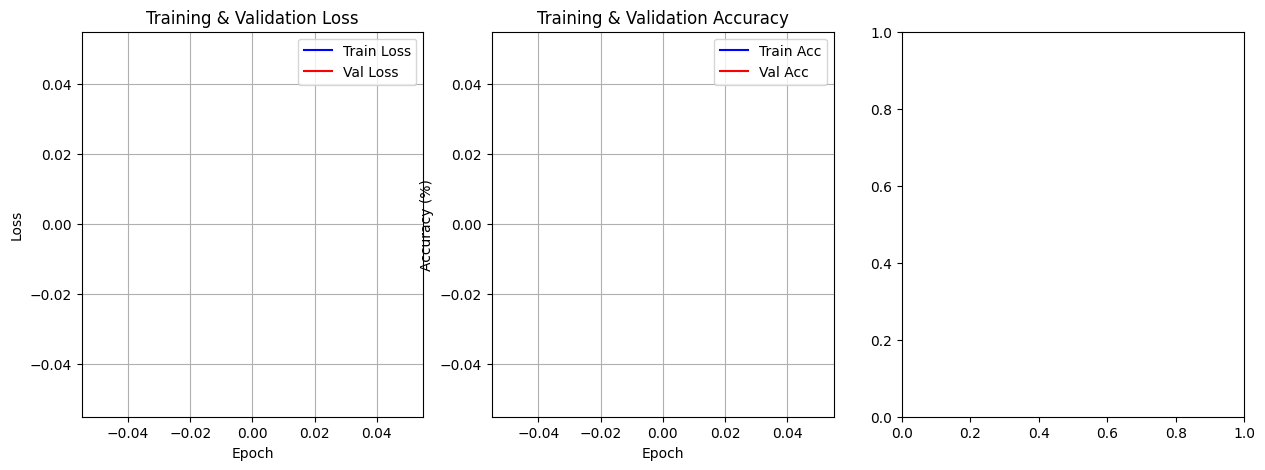

In [ ]:
# Plot training curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(train_losses, label="Train Loss", color="blue")
plt.plot(val_losses, label="Val Loss", color="red")
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curves
plt.subplot(1, 3, 2)
plt.plot(train_accuracies, label="Train Acc", color="blue")
plt.plot(val_accuracies, label="Val Acc", color="red")
plt.title("Training & Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

# Learning rate curve
plt.subplot(1, 3, 3)
lrs = [optimizer.param_groups[0]["lr"]] * len(train_losses)
plt.plot(lrs, label="Learning Rate", color="green")
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("📈 Training curves plotted")

In [ ]:
# 🔄 Load best model and evaluate on test set
print("🔄 Loading best model...")
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"✅ Loaded epoch {checkpoint['epoch']+1}  val_loss={checkpoint['val_loss']:.4f}")

model.eval()
all_predictions, all_labels_list = [], []
test_loss = 0.0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        text = batch["text"].to(device)
        image = batch["image"].to(device)
        labels = batch["label"].to(device)

        loss_dict = model.compute_total_loss(text, image, labels)
        test_loss += loss_dict["total_loss"].item()

        logits = model(text, image)["logits"]
        _, predicted = torch.max(logits, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_accuracy = accuracy_score(all_labels_list, all_predictions)
# re-bind name used by subsequent cells
all_labels = all_labels_list

print(f"\n📊 Final Test Results:")
print(f"  Test Loss:     {avg_test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"\n📋 Classification Report:")
print(
    classification_report(
        all_labels, all_predictions, target_names=["Real", "Fake"], zero_division=0
    )
)

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(f"🔍 Confusion Matrix:")
print(f"  True Negatives (Real→Real): {cm[0,0]}")
print(f"  False Positives (Real→Fake): {cm[0,1]}")
print(f"  False Negatives (Fake→Real): {cm[1,0]}")
print(f"  True Positives (Fake→Fake): {cm[1,1]}")

In [ ]:
# Save final results and model info
results = {
    "model_config": model_config,
    "training_results": {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "best_epoch": checkpoint["epoch"],
        "best_val_loss": checkpoint["val_loss"],
        "best_val_acc": checkpoint["val_acc"],
    },
    "test_results": {
        "test_loss": avg_test_loss,
        "test_accuracy": test_accuracy,
        "confusion_matrix": cm.tolist(),
        "classification_report": classification_report(
            all_labels, all_predictions, target_names=["Real", "Fake"], output_dict=True
        ),
    },
    "dataset_info": {
        "total_samples": len(dataset),
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples": len(test_dataset),
        "text_feature_shape": text_features.shape,
        "image_feature_shape": image_features.shape,
    },
}

# Save results
results_path = "./training_results_resnet50.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"💾 Results saved to {results_path}")
print(f"🧠 Best model saved to {best_model_path}")

print(f"\n🎯 Training Summary:")
print(f"  Model: COOLANT with ResNet50 features")
print(f"  Dataset: {len(dataset)} samples")
print(f"  Best Val Accuracy: {checkpoint['val_acc']:.2f}%")
print(f"  Test Accuracy: {test_accuracy:.2f}%")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")